# Are the contact maps correct?

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

SUMMARY_FILE = "/nfs/scratch/pdb_dimers/contact_maps/contact_map_summary.tsv"
INTERACTION_FILE = "/nfs/scratch/pdb_dimers/final_filtered_interactions_with_partitions.tsv"
SEQUENCE_FILE = "/nfs/scratch/pdb_dimers/unique_sequences_with_partitioning.tsv"
ENTITY_SEQUENCE_PATH = "/nfs/scratch/pdb_dimers/entity_sequences.tsv"

In [45]:
summary_df = pd.read_csv(SUMMARY_FILE, sep="\t")
interaction_df = pd.read_csv(INTERACTION_FILE, sep="\t")

summary_df["assembly_id"] = summary_df["pdb_id"] + "-" + summary_df["assembly_number"].astype(str)

summary_df = summary_df.merge(interaction_df[["assembly_id", "new_cluster_pair"]], on="assembly_id", how="left")

summary_df.head()

,row_index,pdb_id,assembly_number,structure_file,output_file,requested_entity_name_1,requested_entity_name_2,requested_entity_1,requested_entity_2,remapped_entity_1,...,resolved_residues_1,resolved_residues_2,missing_residues_1,missing_residues_2,known_pairs,unknown_pairs,contacts,shape,assembly_id,new_cluster_pair
0,0,10BL,1,10bl-assembly1.cif.gz,10bl-assembly1.npy,10BL_1,10BL_1,1,1,1,...,338,326,23,35,110188,20133,139,361x361,10BL-1,"fix_18845_100,fix_18845_100"
1,1,10FT,1,10ft-assembly1.cif.gz,10ft-assembly1.npy,10FT_1,10FT_2,1,2,1,...,213,562,604,449,119706,706281,125,817x1011,10FT-1,"fix_14530_100,fix_37352_100"
2,2,10JU,1,10ju-assembly1.cif.gz,10ju-assembly1.npy,10JU_1,10JU_2,1,2,1,...,270,252,92,110,68040,63004,41,362x362,10JU-1,"fix_18848_100,fix_18846_100"
3,3,10LI,1,10li-assembly1.cif.gz,10li-assembly1.npy,10LI_1,10LI_1,1,1,1,...,462,462,16,16,213444,15040,262,478x478,10LI-1,"fix_31296_100,fix_31296_100"
4,4,10NM,1,10nm-assembly1.cif.gz,10nm-assembly1.npy,10NM_1,10NM_1,1,1,1,...,448,449,48,47,201152,44864,277,496x496,10NM-1,"fix_20451_100,fix_20451_100"


In [46]:
sequence_df = pd.read_csv(SEQUENCE_FILE, sep="\t")

summary_df[["cluster1", "cluster2"]] = summary_df["new_cluster_pair"].str.split(",", expand=True)

summary_df

,row_index,pdb_id,assembly_number,structure_file,output_file,requested_entity_name_1,requested_entity_name_2,requested_entity_1,requested_entity_2,remapped_entity_1,...,missing_residues_1,missing_residues_2,known_pairs,unknown_pairs,contacts,shape,assembly_id,new_cluster_pair,cluster1,cluster2
0,0,10BL,1,10bl-assembly1.cif.gz,10bl-assembly1.npy,10BL_1,10BL_1,1,1,1,...,23,35,110188,20133,139,361x361,10BL-1,"fix_18845_100,fix_18845_100",fix_18845_100,fix_18845_100
1,1,10FT,1,10ft-assembly1.cif.gz,10ft-assembly1.npy,10FT_1,10FT_2,1,2,1,...,604,449,119706,706281,125,817x1011,10FT-1,"fix_14530_100,fix_37352_100",fix_14530_100,fix_37352_100
2,2,10JU,1,10ju-assembly1.cif.gz,10ju-assembly1.npy,10JU_1,10JU_2,1,2,1,...,92,110,68040,63004,41,362x362,10JU-1,"fix_18848_100,fix_18846_100",fix_18848_100,fix_18846_100
3,3,10LI,1,10li-assembly1.cif.gz,10li-assembly1.npy,10LI_1,10LI_1,1,1,1,...,16,16,213444,15040,262,478x478,10LI-1,"fix_31296_100,fix_31296_100",fix_31296_100,fix_31296_100
4,4,10NM,1,10nm-assembly1.cif.gz,10nm-assembly1.npy,10NM_1,10NM_1,1,1,1,...,48,47,201152,44864,277,496x496,10NM-1,"fix_20451_100,fix_20451_100",fix_20451_100,fix_20451_100
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22088,22088,9ZMZ,1,9zmz-assembly1.cif.gz,9zmz-assembly1.npy,9ZMZ_1,9ZMZ_1,1,1,1,...,13,13,9801,2743,203,112x112,9ZMZ-1,"fix_39175_100,fix_39175_100",fix_39175_100,fix_39175_100
22089,22089,9ZNN,1,9znn-assembly1.cif.gz,9znn-assembly1.npy,9ZNN_1,9ZNN_1,1,1,1,...,35,32,148608,26953,117,419x419,9ZNN-1,"fix_32925_100,fix_32925_100",fix_32925_100,fix_32925_100
22090,22090,9ZNO,1,9zno-assembly1.cif.gz,9zno-assembly1.npy,9ZNO_1,9ZNO_1,1,1,1,...,34,34,109561,23664,67,365x365,9ZNO-1,"fix_13069_100,fix_13069_100",fix_13069_100,fix_13069_100
22091,22091,9ZVM,1,9zvm-assembly1.cif.gz,9zvm-assembly1.npy,9ZVM_1,9ZVM_1,1,1,1,...,411,411,201601,537999,62,860x860,9ZVM-1,"fix_24677_100,fix_24677_100",fix_24677_100,fix_24677_100


In [47]:
sequence_lengths = sequence_df.set_index("new_cluster_id")["sequence"].str.len()

summary_df["new_shape1"] = summary_df["cluster1"].map(sequence_lengths)
summary_df["new_shape2"] = summary_df["cluster2"].map(sequence_lengths)

missing_lengths = summary_df[["new_shape1", "new_shape2"]].isna().any(axis=1)
if missing_lengths.any():
    display(summary_df.loc[missing_lengths, ["pdb_id", "cluster1", "cluster2", "new_shape1", "new_shape2"]])
    raise ValueError("Some cluster IDs were not found in sequence_df")

summary_df["new_shape1"] = summary_df["new_shape1"].astype(int)
summary_df["new_shape2"] = summary_df["new_shape2"].astype(int)
summary_df["control_shape"] = summary_df["new_shape1"].astype(str) + "x" + summary_df["new_shape2"].astype(str)

summary_df

,row_index,pdb_id,assembly_number,structure_file,output_file,requested_entity_name_1,requested_entity_name_2,requested_entity_1,requested_entity_2,remapped_entity_1,...,unknown_pairs,contacts,shape,assembly_id,new_cluster_pair,cluster1,cluster2,new_shape1,new_shape2,control_shape
0,0,10BL,1,10bl-assembly1.cif.gz,10bl-assembly1.npy,10BL_1,10BL_1,1,1,1,...,20133,139,361x361,10BL-1,"fix_18845_100,fix_18845_100",fix_18845_100,fix_18845_100,361,361,361x361
1,1,10FT,1,10ft-assembly1.cif.gz,10ft-assembly1.npy,10FT_1,10FT_2,1,2,1,...,706281,125,817x1011,10FT-1,"fix_14530_100,fix_37352_100",fix_14530_100,fix_37352_100,817,1011,817x1011
2,2,10JU,1,10ju-assembly1.cif.gz,10ju-assembly1.npy,10JU_1,10JU_2,1,2,1,...,63004,41,362x362,10JU-1,"fix_18848_100,fix_18846_100",fix_18848_100,fix_18846_100,362,362,362x362
3,3,10LI,1,10li-assembly1.cif.gz,10li-assembly1.npy,10LI_1,10LI_1,1,1,1,...,15040,262,478x478,10LI-1,"fix_31296_100,fix_31296_100",fix_31296_100,fix_31296_100,478,478,478x478
4,4,10NM,1,10nm-assembly1.cif.gz,10nm-assembly1.npy,10NM_1,10NM_1,1,1,1,...,44864,277,496x496,10NM-1,"fix_20451_100,fix_20451_100",fix_20451_100,fix_20451_100,496,496,496x496
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22088,22088,9ZMZ,1,9zmz-assembly1.cif.gz,9zmz-assembly1.npy,9ZMZ_1,9ZMZ_1,1,1,1,...,2743,203,112x112,9ZMZ-1,"fix_39175_100,fix_39175_100",fix_39175_100,fix_39175_100,112,112,112x112
22089,22089,9ZNN,1,9znn-assembly1.cif.gz,9znn-assembly1.npy,9ZNN_1,9ZNN_1,1,1,1,...,26953,117,419x419,9ZNN-1,"fix_32925_100,fix_32925_100",fix_32925_100,fix_32925_100,419,419,419x419
22090,22090,9ZNO,1,9zno-assembly1.cif.gz,9zno-assembly1.npy,9ZNO_1,9ZNO_1,1,1,1,...,23664,67,365x365,9ZNO-1,"fix_13069_100,fix_13069_100",fix_13069_100,fix_13069_100,365,365,365x365
22091,22091,9ZVM,1,9zvm-assembly1.cif.gz,9zvm-assembly1.npy,9ZVM_1,9ZVM_1,1,1,1,...,537999,62,860x860,9ZVM-1,"fix_24677_100,fix_24677_100",fix_24677_100,fix_24677_100,860,860,860x860


In [48]:
summary_df[["old_shape1", "old_shape2"]] = summary_df["shape"].str.split("x", expand=True)

summary_df

,row_index,pdb_id,assembly_number,structure_file,output_file,requested_entity_name_1,requested_entity_name_2,requested_entity_1,requested_entity_2,remapped_entity_1,...,shape,assembly_id,new_cluster_pair,cluster1,cluster2,new_shape1,new_shape2,control_shape,old_shape1,old_shape2
0,0,10BL,1,10bl-assembly1.cif.gz,10bl-assembly1.npy,10BL_1,10BL_1,1,1,1,...,361x361,10BL-1,"fix_18845_100,fix_18845_100",fix_18845_100,fix_18845_100,361,361,361x361,361,361
1,1,10FT,1,10ft-assembly1.cif.gz,10ft-assembly1.npy,10FT_1,10FT_2,1,2,1,...,817x1011,10FT-1,"fix_14530_100,fix_37352_100",fix_14530_100,fix_37352_100,817,1011,817x1011,817,1011
2,2,10JU,1,10ju-assembly1.cif.gz,10ju-assembly1.npy,10JU_1,10JU_2,1,2,1,...,362x362,10JU-1,"fix_18848_100,fix_18846_100",fix_18848_100,fix_18846_100,362,362,362x362,362,362
3,3,10LI,1,10li-assembly1.cif.gz,10li-assembly1.npy,10LI_1,10LI_1,1,1,1,...,478x478,10LI-1,"fix_31296_100,fix_31296_100",fix_31296_100,fix_31296_100,478,478,478x478,478,478
4,4,10NM,1,10nm-assembly1.cif.gz,10nm-assembly1.npy,10NM_1,10NM_1,1,1,1,...,496x496,10NM-1,"fix_20451_100,fix_20451_100",fix_20451_100,fix_20451_100,496,496,496x496,496,496
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22088,22088,9ZMZ,1,9zmz-assembly1.cif.gz,9zmz-assembly1.npy,9ZMZ_1,9ZMZ_1,1,1,1,...,112x112,9ZMZ-1,"fix_39175_100,fix_39175_100",fix_39175_100,fix_39175_100,112,112,112x112,112,112
22089,22089,9ZNN,1,9znn-assembly1.cif.gz,9znn-assembly1.npy,9ZNN_1,9ZNN_1,1,1,1,...,419x419,9ZNN-1,"fix_32925_100,fix_32925_100",fix_32925_100,fix_32925_100,419,419,419x419,419,419
22090,22090,9ZNO,1,9zno-assembly1.cif.gz,9zno-assembly1.npy,9ZNO_1,9ZNO_1,1,1,1,...,365x365,9ZNO-1,"fix_13069_100,fix_13069_100",fix_13069_100,fix_13069_100,365,365,365x365,365,365
22091,22091,9ZVM,1,9zvm-assembly1.cif.gz,9zvm-assembly1.npy,9ZVM_1,9ZVM_1,1,1,1,...,860x860,9ZVM-1,"fix_24677_100,fix_24677_100",fix_24677_100,fix_24677_100,860,860,860x860,860,860


In [49]:
# Check whether any shapes are not identical
# faulty_summary_df = summary_df[(summary_df["new_shape1"].eq(summary_df["old_shape1"]) | summary_df["new_shape1"].eq(summary_df["old_shape2"])) & (summary_df["new_shape2"].eq(summary_df["old_shape1"]) | summary_df["new_shape2"].eq(summary_df["old_shape2"]))].copy()
faulty_summary_df = summary_df[summary_df["shape"] != summary_df["control_shape"]]

faulty_summary_df

,row_index,pdb_id,assembly_number,structure_file,output_file,requested_entity_name_1,requested_entity_name_2,requested_entity_1,requested_entity_2,remapped_entity_1,...,shape,assembly_id,new_cluster_pair,cluster1,cluster2,new_shape1,new_shape2,control_shape,old_shape1,old_shape2


In [50]:
# are any faulty ones in the interaction DF ??
faulty_summary_df[faulty_summary_df["pdb_id"].isin(interaction_df["pdb_id"])]

,row_index,pdb_id,assembly_number,structure_file,output_file,requested_entity_name_1,requested_entity_name_2,requested_entity_1,requested_entity_2,remapped_entity_1,...,shape,assembly_id,new_cluster_pair,cluster1,cluster2,new_shape1,new_shape2,control_shape,old_shape1,old_shape2


## new approach

In [51]:
summary_df = pd.read_csv(SUMMARY_FILE, sep="\t")
entitiy_sequence_df = pd.read_csv(ENTITY_SEQUENCE_PATH, sep="\t")
interaction_df = pd.read_csv(INTERACTION_FILE, sep="\t")

summary_df = summary_df.merge(interaction_df[["pdb_id", "entity_pair"]], on="pdb_id", how="left")

summary_df.head()


,row_index,pdb_id,assembly_number,structure_file,output_file,requested_entity_name_1,requested_entity_name_2,requested_entity_1,requested_entity_2,remapped_entity_1,...,residues_2,resolved_residues_1,resolved_residues_2,missing_residues_1,missing_residues_2,known_pairs,unknown_pairs,contacts,shape,entity_pair
0,0,10BL,1,10bl-assembly1.cif.gz,10bl-assembly1.npy,10BL_1,10BL_1,1,1,1,...,361,338,326,23,35,110188,20133,139,361x361,"10BL_1,10BL_1"
1,1,10FT,1,10ft-assembly1.cif.gz,10ft-assembly1.npy,10FT_1,10FT_2,1,2,1,...,1011,213,562,604,449,119706,706281,125,817x1011,"10FT_1,10FT_2"
2,2,10JU,1,10ju-assembly1.cif.gz,10ju-assembly1.npy,10JU_1,10JU_2,1,2,1,...,362,270,252,92,110,68040,63004,41,362x362,"10JU_1,10JU_2"
3,3,10LI,1,10li-assembly1.cif.gz,10li-assembly1.npy,10LI_1,10LI_1,1,1,1,...,478,462,462,16,16,213444,15040,262,478x478,"10LI_1,10LI_1"
4,4,10NM,1,10nm-assembly1.cif.gz,10nm-assembly1.npy,10NM_1,10NM_1,1,1,1,...,496,448,449,48,47,201152,44864,277,496x496,"10NM_1,10NM_1"


# How sparse are the contact maps (General overview)

In [52]:
summary_df = pd.read_csv(SUMMARY_FILE, sep="\t")

summary_df.head()

,row_index,pdb_id,assembly_number,structure_file,output_file,requested_entity_name_1,requested_entity_name_2,requested_entity_1,requested_entity_2,remapped_entity_1,...,residues_1,residues_2,resolved_residues_1,resolved_residues_2,missing_residues_1,missing_residues_2,known_pairs,unknown_pairs,contacts,shape
0,0,10BL,1,10bl-assembly1.cif.gz,10bl-assembly1.npy,10BL_1,10BL_1,1,1,1,...,361,361,338,326,23,35,110188,20133,139,361x361
1,1,10FT,1,10ft-assembly1.cif.gz,10ft-assembly1.npy,10FT_1,10FT_2,1,2,1,...,817,1011,213,562,604,449,119706,706281,125,817x1011
2,2,10JU,1,10ju-assembly1.cif.gz,10ju-assembly1.npy,10JU_1,10JU_2,1,2,1,...,362,362,270,252,92,110,68040,63004,41,362x362
3,3,10LI,1,10li-assembly1.cif.gz,10li-assembly1.npy,10LI_1,10LI_1,1,1,1,...,478,478,462,462,16,16,213444,15040,262,478x478
4,4,10NM,1,10nm-assembly1.cif.gz,10nm-assembly1.npy,10NM_1,10NM_1,1,1,1,...,496,496,448,449,48,47,201152,44864,277,496x496


In [53]:
# how sparse are the contact maps ?
summary_df["sparsity"] = summary_df["contacts"] / (summary_df["residues_1"] * summary_df["residues_2"] - summary_df["unknown_pairs"])

summary_df[["shape", "unknown_pairs", "sparsity"]].head()

,shape,unknown_pairs,sparsity
0,361x361,20133,0.001261
1,817x1011,706281,0.001044
2,362x362,63004,0.000603
3,478x478,15040,0.001227
4,496x496,44864,0.001377


In [54]:
# average sparsity
np.sum(summary_df["sparsity"]) / len(summary_df)

np.float64(0.003326326653768668)

In [55]:
# maximal sparsity
np.max(summary_df["sparsity"])

np.float64(0.17729591836734693)

In [56]:
summary_df.iloc[summary_df["sparsity"].argmax()]

row_index                                  20275
pdb_id                                      8UG2
assembly_number                                1
structure_file             8ug2-assembly1.cif.gz
output_file                   8ug2-assembly1.npy
requested_entity_name_1                   8UG2_1
requested_entity_name_2                   8UG2_2
requested_entity_1                             1
requested_entity_2                             2
remapped_entity_1                              1
remapped_entity_2                              2
chain_1                                        A
chain_2                                        B
residues_1                                    56
residues_2                                    56
resolved_residues_1                           56
resolved_residues_2                           56
missing_residues_1                             0
missing_residues_2                             0
known_pairs                                 3136
unknown_pairs       

In [57]:
summary_df[["pdb_id", "sparsity"]].nlargest(n=5, columns=["sparsity"])

,pdb_id,sparsity
20275,8UG2,0.177296
20274,8UG0,0.174745
4241,2JKU,0.109388
6067,3C03,0.065278
13303,5ITJ,0.065104


In [58]:
# minimal sparsityy
np.min(summary_df["sparsity"])

np.float64(0.0)

In [59]:
summary_df[summary_df["sparsity"] == 0.0]



,row_index,pdb_id,assembly_number,structure_file,output_file,requested_entity_name_1,requested_entity_name_2,requested_entity_1,requested_entity_2,remapped_entity_1,...,residues_2,resolved_residues_1,resolved_residues_2,missing_residues_1,missing_residues_2,known_pairs,unknown_pairs,contacts,shape,sparsity
1823,1823,1QHZ,2,1qhz-assembly2.cif.gz,1qhz-assembly2.npy,1QHZ_1,1QHZ_1,1,1,1,...,305,302,302,3,3,91204,1821,0,305x305,0.0
3138,3138,2ATQ,1,2atq-assembly1.cif.gz,2atq-assembly1.npy,2ATQ_1,2ATQ_2,1,2,1,...,234,845,210,58,24,177450,33852,0,903x234,0.0
9566,9566,4BKG,1,4bkg-assembly1.cif.gz,4bkg-assembly1.npy,4BKG_1,4BKG_1,1,1,1,...,168,73,73,95,95,5329,22895,0,168x168,0.0
9753,9753,4DDJ,1,4ddj-assembly1.cif.gz,4ddj-assembly1.npy,4DDJ_1,4DDJ_1,1,1,1,...,83,80,80,3,3,6400,489,0,83x83,0.0
11263,11263,4OAZ,1,4oaz-assembly1.cif.gz,4oaz-assembly1.npy,4OAZ_1,4OAZ_1,1,1,1,...,92,72,75,20,17,5400,3064,0,92x92,0.0
11879,11879,4UPF,1,4upf-assembly1.cif.gz,4upf-assembly1.npy,4UPF_1,4UPF_2,1,2,1,...,115,710,74,5,41,52540,29685,0,715x115,0.0
12354,12354,4ZMM,1,4zmm-assembly1.cif.gz,4zmm-assembly1.npy,4ZMM_1,4ZMM_1,1,1,1,...,223,164,161,59,62,26404,23325,0,223x223,0.0
13490,13490,5KHD,1,5khd-assembly1.cif.gz,5khd-assembly1.npy,5KHD_1,5KHD_1,1,1,1,...,91,73,72,18,19,5256,3025,0,91x91,0.0
14038,14038,5TZG,1,5tzg-assembly1.cif.gz,5tzg-assembly1.npy,5TZG_1,5TZG_1,1,1,1,...,91,76,75,15,16,5700,2581,0,91x91,0.0
15553,15553,6IAR,1,6iar-assembly1.cif.gz,6iar-assembly1.npy,6IAR_1,6IAR_1,1,1,1,...,237,237,237,0,0,56169,0,0,237x237,0.0


In [60]:
filtered_summary_df = summary_df[summary_df["sparsity"] != 0.0].copy()

np.min(filtered_summary_df["sparsity"])

np.float64(5.370333739390235e-06)

In [61]:
filtered_summary_df[filtered_summary_df["sparsity"] == 5.370333739390235e-06]

,row_index,pdb_id,assembly_number,structure_file,output_file,requested_entity_name_1,requested_entity_name_2,requested_entity_1,requested_entity_2,remapped_entity_1,...,residues_2,resolved_residues_1,resolved_residues_2,missing_residues_1,missing_residues_2,known_pairs,unknown_pairs,contacts,shape,sparsity
18585,18585,7WHP,1,7whp-assembly1.cif.gz,7whp-assembly1.npy,7WHP_1,7WHP_1,1,1,1,...,1058,1057,1057,1,1,1117249,2115,6,1058x1058,0.000005


### Density plot of sparsity distribution

In [62]:
# remove unwanted entries
blacklist = ["8UG2", "8UG0"]

print(f"size before: {len(filtered_summary_df)}")
filtered_summary_df = filtered_summary_df[~filtered_summary_df["pdb_id"].isin(blacklist)]
print(f"size after: {len(filtered_summary_df)}")

size before: 22072
size after: 22070


In [63]:
filtered_summary_df[filtered_summary_df["pdb_id"] == "8UG0"]

,row_index,pdb_id,assembly_number,structure_file,output_file,requested_entity_name_1,requested_entity_name_2,requested_entity_1,requested_entity_2,remapped_entity_1,...,residues_2,resolved_residues_1,resolved_residues_2,missing_residues_1,missing_residues_2,known_pairs,unknown_pairs,contacts,shape,sparsity


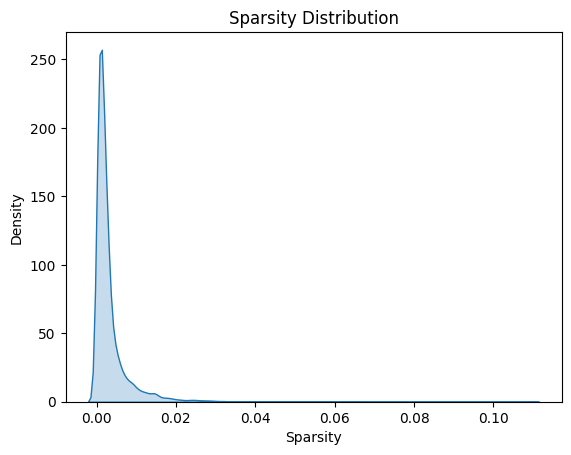

In [66]:
# plot sparsity
sns.kdeplot(data=filtered_summary_df, x="sparsity", fill=True)

plt.xlabel("Sparsity")
plt.ylabel("Density")
plt.title("Sparsity Distribution")
plt.show()